# CyberTrace Cluster Exploration

Use this notebook to inspect the starter feature table, run clustering, and begin writing analyst notes about what each cluster suggests.

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

FEATURES_PATH = Path('../data/processed/features.csv')
REPORTS_PATH = Path('../reports/clusters.csv')
FIGURE_PATH = Path('../reports/figures/starter_clusters.png')

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv(FEATURES_PATH)
df.head()

,sample_id,label,source,connection_count,unique_destinations,unique_ports,avg_packet_size,packet_size_std,tcp_ratio,udp_ratio,dns_query_count,http_request_count,failed_connection_ratio,beacon_score,bytes_out_ratio,duration_seconds
0,benign_001,benign,starter_synthetic,18,9,6,512.4,120.5,0.72,0.18,4,8,0.03,0.08,0.47,95
1,benign_002,benign,starter_synthetic,24,12,8,548.2,135.1,0.69,0.21,5,11,0.04,0.10,0.52,130
2,benign_003,benign,starter_synthetic,15,7,5,489.7,110.3,0.75,0.15,3,6,0.02,0.07,0.44,80
3,benign_004,benign,starter_synthetic,31,14,9,590.5,142.8,0.70,0.20,6,14,0.05,0.12,0.50,155
4,benign_005,benign,starter_synthetic,21,10,7,530.9,128.9,0.73,0.17,4,9,0.03,0.09,0.48,105


In [3]:
metadata_columns = ['sample_id', 'label', 'source']
features = df.drop(columns=metadata_columns).select_dtypes(include='number')

scaled = StandardScaler().fit_transform(features)
clusters = KMeans(n_clusters=3, random_state=42, n_init='auto').fit_predict(scaled)

assignments = df[metadata_columns].copy()
assignments['cluster'] = clusters
assignments.groupby(['cluster', 'label']).size().reset_index(name='sample_count')

,cluster,label,sample_count
0,0,malicious,6
1,0,suspicious,6
2,1,benign,3
3,2,benign,3


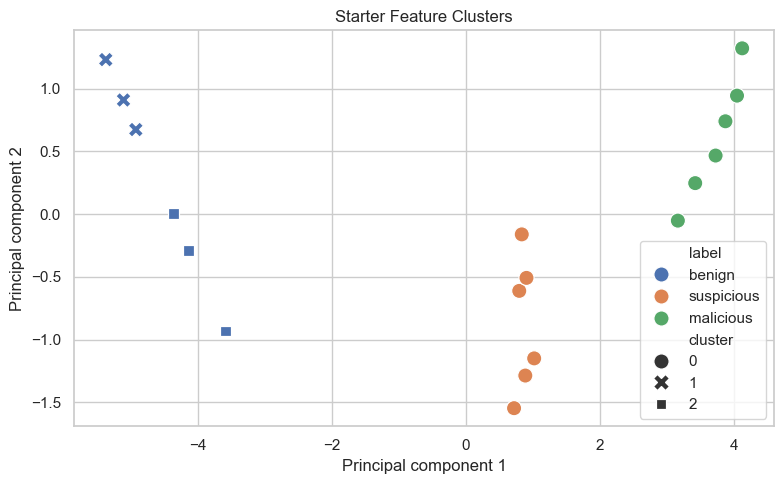

In [4]:
pca = PCA(n_components=2, random_state=42)
points = pca.fit_transform(scaled)
plot_df = assignments.assign(pc1=points[:, 0], pc2=points[:, 1])

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='label', style='cluster', s=120, ax=ax)
ax.set_title('Starter Feature Clusters')
ax.set_xlabel('Principal component 1')
ax.set_ylabel('Principal component 2')
fig.tight_layout()

FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, dpi=160)
plt.show()

In [5]:
REPORTS_PATH.parent.mkdir(parents=True, exist_ok=True)
assignments.to_csv(REPORTS_PATH, index=False)
assignments

,sample_id,label,source,cluster
0,benign_001,benign,starter_synthetic,2
1,benign_002,benign,starter_synthetic,1
2,benign_003,benign,starter_synthetic,2
3,benign_004,benign,starter_synthetic,1
4,benign_005,benign,starter_synthetic,2
5,benign_006,benign,starter_synthetic,1
6,suspicious_001,suspicious,starter_synthetic,0
7,suspicious_002,suspicious,starter_synthetic,0
8,suspicious_003,suspicious,starter_synthetic,0
9,suspicious_004,suspicious,starter_synthetic,0


## Analyst Notes

- Benign-like samples should show moderate destination diversity, more HTTP activity, and lower beaconing.
- Suspicious samples should show fewer destinations, more DNS activity, higher failed connection ratios, and repeated timing.
- Malicious-like samples should show the strongest beaconing, high outbound byte ratios, and concentrated destination behavior.

Replace these starter notes as real artifacts are collected and analyzed.